In [3]:
!pip install plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries ready!')

✅ All libraries ready!


Load All 3 Files

In [4]:
drinks  = pd.read_csv('starbucks-menu-nutrition-drinks.csv', encoding='latin1')
expand  = pd.read_csv('starbucks_drinkMenu_expanded.csv',    encoding='latin1')

# Food file is UTF-16 encoded
food_raw = pd.read_csv('starbucks-menu-nutrition-food.csv', encoding='utf-16')
print("Food columns:", food_raw.columns.tolist())
print(food_raw.head(3))

Food columns: ['Unnamed: 0', ' Calories', ' Fat (g)', ' Carb. (g)', ' Fiber (g)', ' Protein (g)']
         Unnamed: 0   Calories   Fat (g)   Carb. (g)   Fiber (g)   Protein (g)
0      Chonga Bagel        300       5.0          50           3            12
1      8-Grain Roll        380       6.0          70           7            10
2  Almond Croissant        410      22.0          45           3            10


In [5]:
# ── Expanded (main) ──────────────────────────────
expand.columns = expand.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'pct')

# 👇 ADD THIS to see exact column names
print("Exact columns after cleaning:")
for col in expand.columns:
    print(f"  '{col}'")

Exact columns after cleaning:
  'Beverage_category'
  'Beverage'
  'Beverage_prep'
  'Calories'
  'Total_Fat_g'
  'Trans_Fat_g'
  'Saturated_Fat_g'
  'Sodium_mg'
  'Total_Carbohydrates_g'
  'Cholesterol_mg'
  'Dietary_Fibre_g'
  'Sugars_g'
  'Protein_g'
  'Vitamin_A_pct_DV'
  'Vitamin_C_pct_DV'
  'Calcium_pct_DV'
  'Iron_pct_DV'
  'Caffeine_mg'


Clean All 3 Datasets

In [6]:
# ── Expanded (main) ──────────────────────────────
expand.columns = expand.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'pct')

expand['Calories']    = pd.to_numeric(expand['Calories'],    errors='coerce')
expand['Caffeine_mg'] = pd.to_numeric(expand['Caffeine_mg'], errors='coerce')
expand['Sugars_g']    = pd.to_numeric(expand['Sugars_g'],    errors='coerce')
expand['Fat_g']       = pd.to_numeric(expand['Total_Fat_g'], errors='coerce')
expand['Protein_g']   = pd.to_numeric(expand['Protein_g'],   errors='coerce')
expand.dropna(subset=['Calories'], inplace=True)

# ── Drinks ────────────────────────────────────────
drinks.rename(columns={'Unnamed: 0': 'Beverage', 'Fat (g)': 'Fat_g',
                        'Carb. (g)': 'Carb_g', 'Protein': 'Protein_g'}, inplace=True)
drinks['Calories'] = pd.to_numeric(drinks['Calories'], errors='coerce')
drinks.dropna(subset=['Calories'], inplace=True)

# ── Food ──────────────────────────────────────────
food = food_raw.copy()
food.columns = ['Item', 'Calories', 'Fat_g', 'Carb_g', 'Fiber_g', 'Protein_g']
food['Item']     = food['Item'].astype(str).str.strip()
food['Calories'] = pd.to_numeric(food['Calories'], errors='coerce')
food = food[food['Item'] != 'nan']
food.dropna(subset=['Calories'], inplace=True)

print(f'✅ Food cleaned: {len(food)} rows')
print(food[['Item', 'Calories']].head(5))

✅ Food cleaned: 113 rows
               Item  Calories
0      Chonga Bagel       300
1      8-Grain Roll       380
2  Almond Croissant       410
3     Apple Fritter       460
4  Banana Nut Bread       420


VIZ 1: Top 10 Highest Calorie Drinks

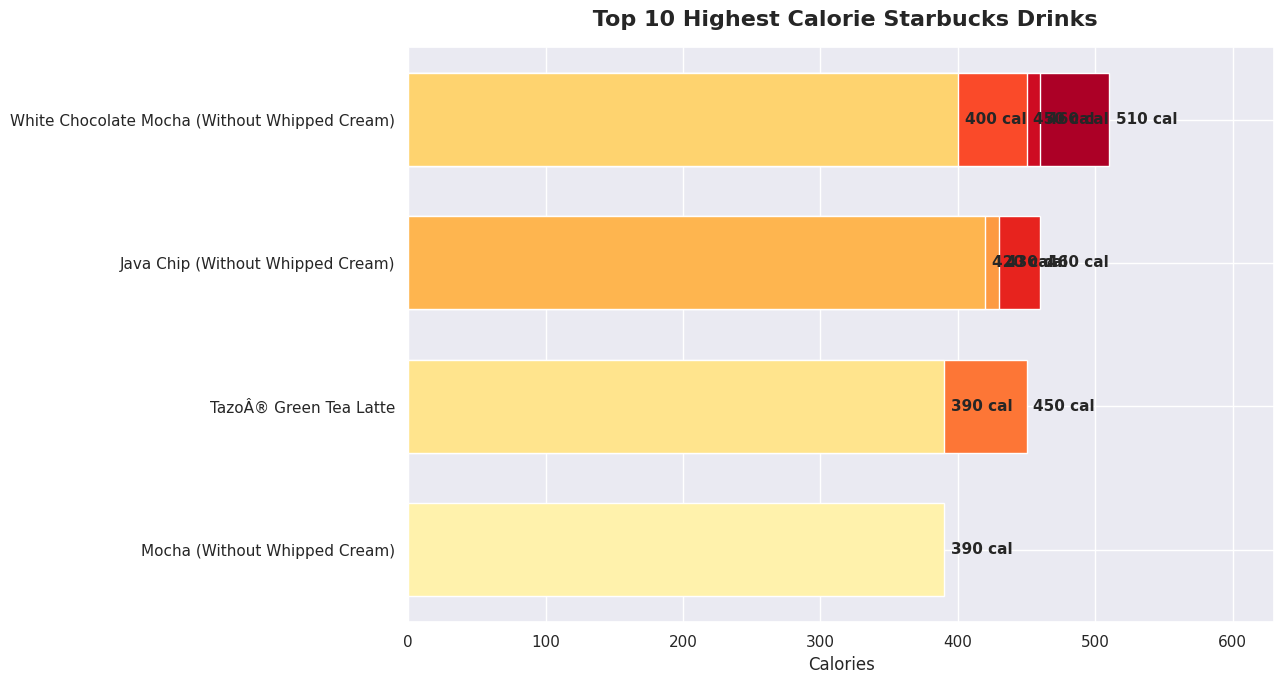

In [7]:
top10 = expand.nlargest(10, 'Calories')[['Beverage', 'Beverage_category', 'Calories']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 7))
colors = sns.color_palette('YlOrRd', 10)[::-1]
bars = ax.barh(top10['Beverage'], top10['Calories'],
               color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, top10['Calories']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(val)} cal', va='center', fontweight='bold', fontsize=11)

ax.set_title(' Top 10 Highest Calorie Starbucks Drinks', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Calories', fontsize=12)
ax.set_xlim(0, top10['Calories'].max() + 120)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz1_top10_calories.png', dpi=150, bbox_inches='tight')
plt.show()

VIZ 2: Average Calories by Category

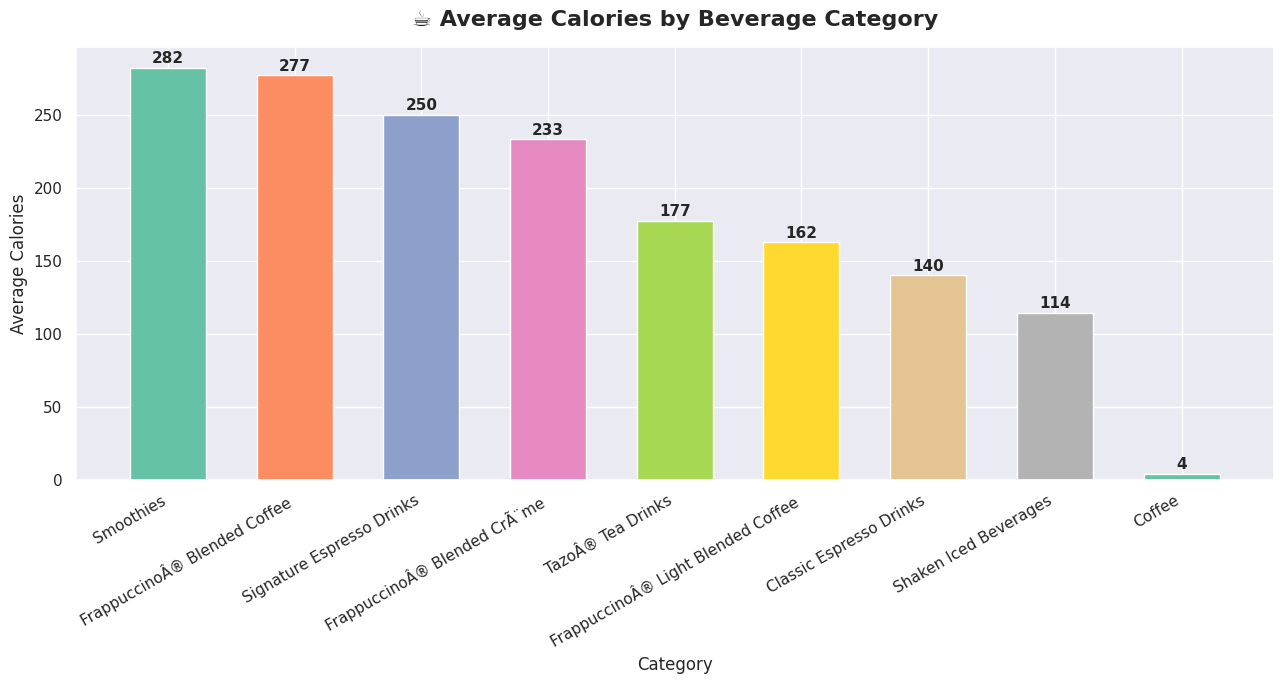

In [8]:
cat_avg = expand.groupby('Beverage_category')['Calories'].mean().sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('Set2', len(cat_avg))
bars = ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor='white', width=0.6)

for bar, val in zip(bars, cat_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', fontweight='bold', fontsize=11)

ax.set_title('☕ Average Calories by Beverage Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Average Calories', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz2_category_avg.png', dpi=150, bbox_inches='tight')
plt.show()

VIZ 3: Sugar vs Calories Scatter

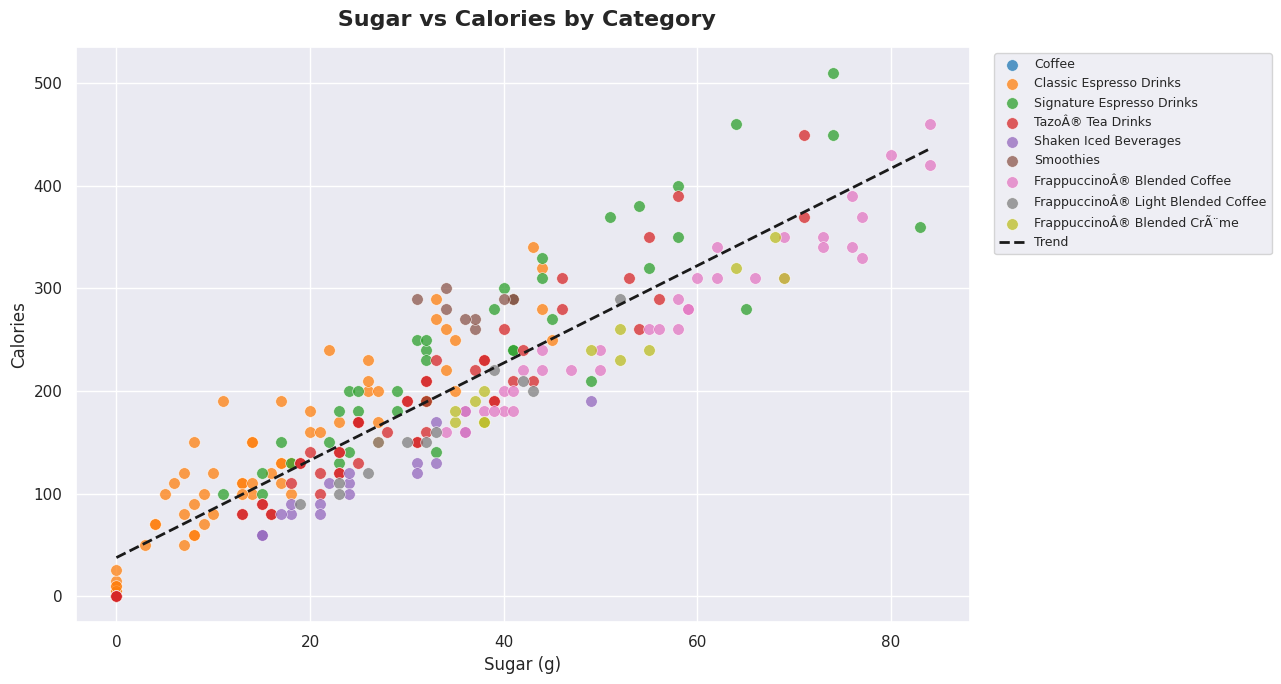

In [9]:
fig, ax = plt.subplots(figsize=(13, 7))

categories = expand['Beverage_category'].dropna().unique()
palette = sns.color_palette('tab10', len(categories))
color_map = dict(zip(categories, palette))

for cat in categories:
    sub = expand[expand['Beverage_category'] == cat]
    ax.scatter(sub['Sugars_g'], sub['Calories'],
               label=cat, alpha=0.75, s=70,
               color=color_map[cat], edgecolors='white', linewidth=0.5)

# Trend line
valid = expand.dropna(subset=['Sugars_g', 'Calories'])
z = np.polyfit(valid['Sugars_g'], valid['Calories'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['Sugars_g'].min(), valid['Sugars_g'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')

ax.set_title(' Sugar vs Calories by Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sugar (g)', fontsize=12)
ax.set_ylabel('Calories', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('viz3_sugar_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

 VIZ 4: Caffeine King

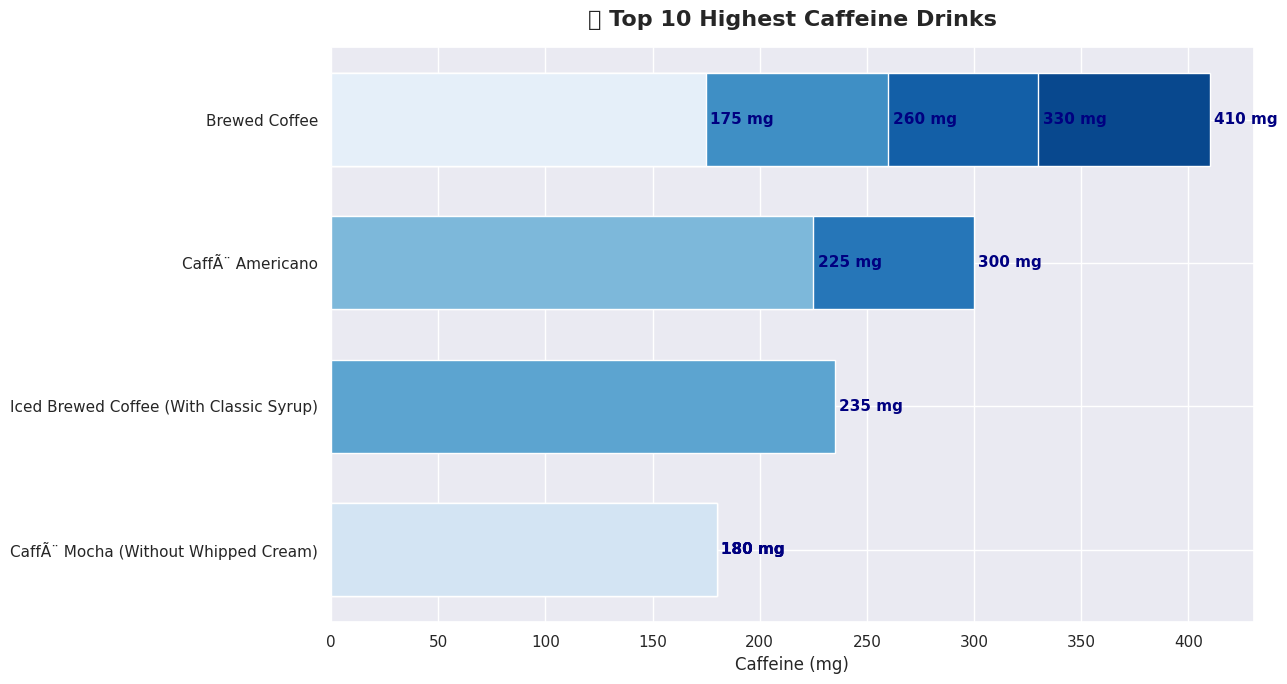

In [10]:
caf = expand.dropna(subset=['Caffeine_mg'])
top_caf = caf.nlargest(10, 'Caffeine_mg')[['Beverage', 'Caffeine_mg']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 7))
colors_c = sns.color_palette('Blues_r', 10)
bars = ax.barh(top_caf['Beverage'], top_caf['Caffeine_mg'],
               color=colors_c, edgecolor='white', height=0.65)

for bar, val in zip(bars, top_caf['Caffeine_mg']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{int(val)} mg', va='center', fontweight='bold', fontsize=11, color='navy')

ax.set_title('👑 Top 10 Highest Caffeine Drinks', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Caffeine (mg)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz4_caffeine.png', dpi=150, bbox_inches='tight')
plt.show()

 VIZ 5: Nutrition Radar Chart

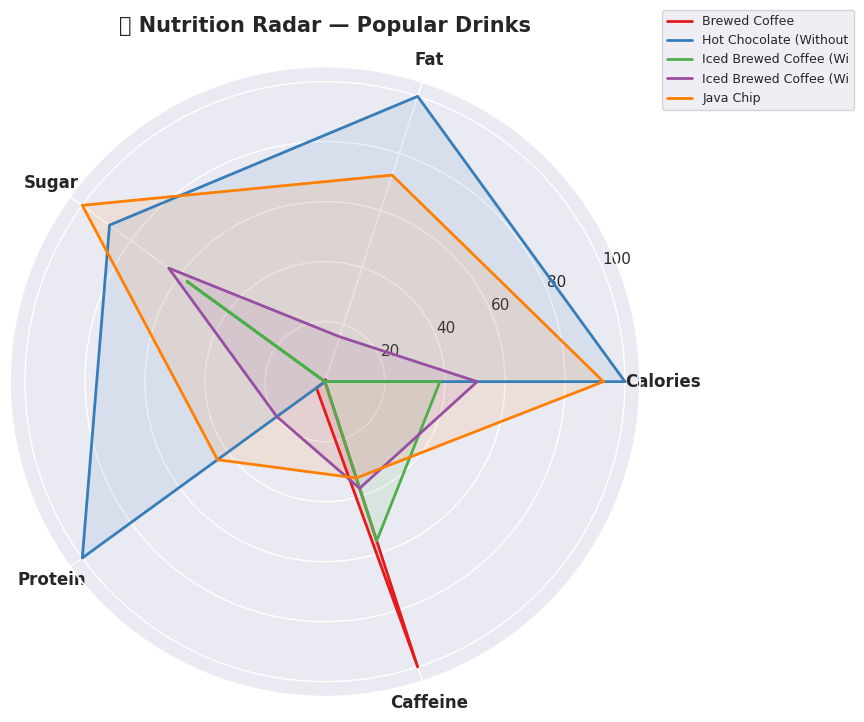

In [11]:
# Pick 5 representative drinks from expanded dataset
picks = ['Brewed Coffee', 'Caffe Latte', 'Hot Chocolate', 'Java Chip', 'Tazo']
selected = expand[expand['Beverage'].str.contains('|'.join(picks), case=False, na=False)]
selected = selected.groupby('Beverage')[['Calories','Fat_g','Sugars_g','Protein_g','Caffeine_mg']].mean().reset_index().head(5)

cols = ['Calories','Fat_g','Sugars_g','Protein_g','Caffeine_mg']
norm = selected[cols].copy()
for col in cols:
    rng = norm[col].max() - norm[col].min()
    norm[col] = (norm[col] - norm[col].min()) / (rng if rng > 0 else 1) * 100

N = len(cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = sns.color_palette('Set1', len(norm))

for i, row in norm.iterrows():
    vals = row[cols].tolist() + [row[cols[0]]]
    ax.plot(angles, vals, linewidth=2, color=colors_r[i],
            label=selected.iloc[i]['Beverage'][:22])
    ax.fill(angles, vals, alpha=0.1, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Calories','Fat','Sugar','Protein','Caffeine'], fontsize=12, fontweight='bold')
ax.set_title('🕸️ Nutrition Radar — Popular Drinks', fontsize=15, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('viz5_radar.png', dpi=150, bbox_inches='tight')
plt.show()

VIZ 6: Drinks vs Food Calories

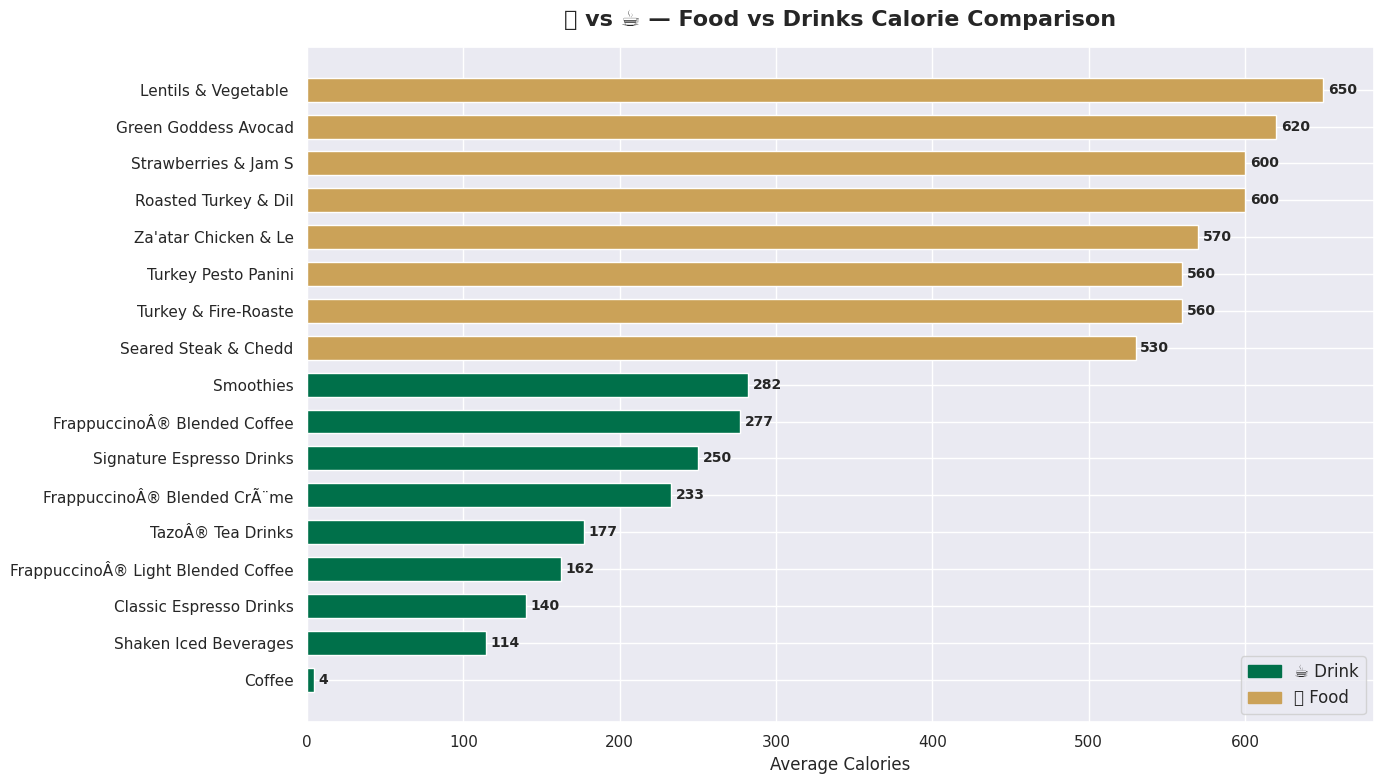

💡 Surprising? Some drinks pack more calories than food!


In [12]:
# ── Food vs Drinks Calorie Comparison ──────────────
drink_avg = expand.groupby('Beverage_category')['Calories'].mean().reset_index()
drink_avg.columns = ['Category', 'Avg_Calories']
drink_avg['Type'] = '☕ Drink'

# Fix: convert Item to string first
food_sample = food.copy()
food_sample['Item'] = food_sample['Item'].astype(str).str.strip()
food_sample = food_sample[food_sample['Item'] != 'nan']
food_sample['Category'] = food_sample['Item'].str[:20]
food_avg = food_sample.groupby('Category')['Calories'].mean().reset_index()
food_avg.columns = ['Category', 'Avg_Calories']
food_avg = food_avg.nlargest(8, 'Avg_Calories')
food_avg['Type'] = '🍔 Food'

combined = pd.concat([drink_avg, food_avg], ignore_index=True).sort_values('Avg_Calories', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
color_map2 = {'☕ Drink': '#00704A', '🍔 Food': '#CBA258'}
colors_comb = [color_map2[t] for t in combined['Type']]

bars = ax.barh(combined['Category'], combined['Avg_Calories'],
               color=colors_comb, edgecolor='white', height=0.65)

for bar, val in zip(bars, combined['Avg_Calories']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontweight='bold', fontsize=10)

green_patch = mpatches.Patch(color='#00704A', label='☕ Drink')
gold_patch  = mpatches.Patch(color='#CBA258', label='🍔 Food')
ax.legend(handles=[green_patch, gold_patch], fontsize=12)

ax.set_title('🍔 vs ☕ — Food vs Drinks Calorie Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Calories', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz6_food_vs_drinks.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Surprising? Some drinks pack more calories than food!')

VIZ 7: Calorie Distribution Boxplot

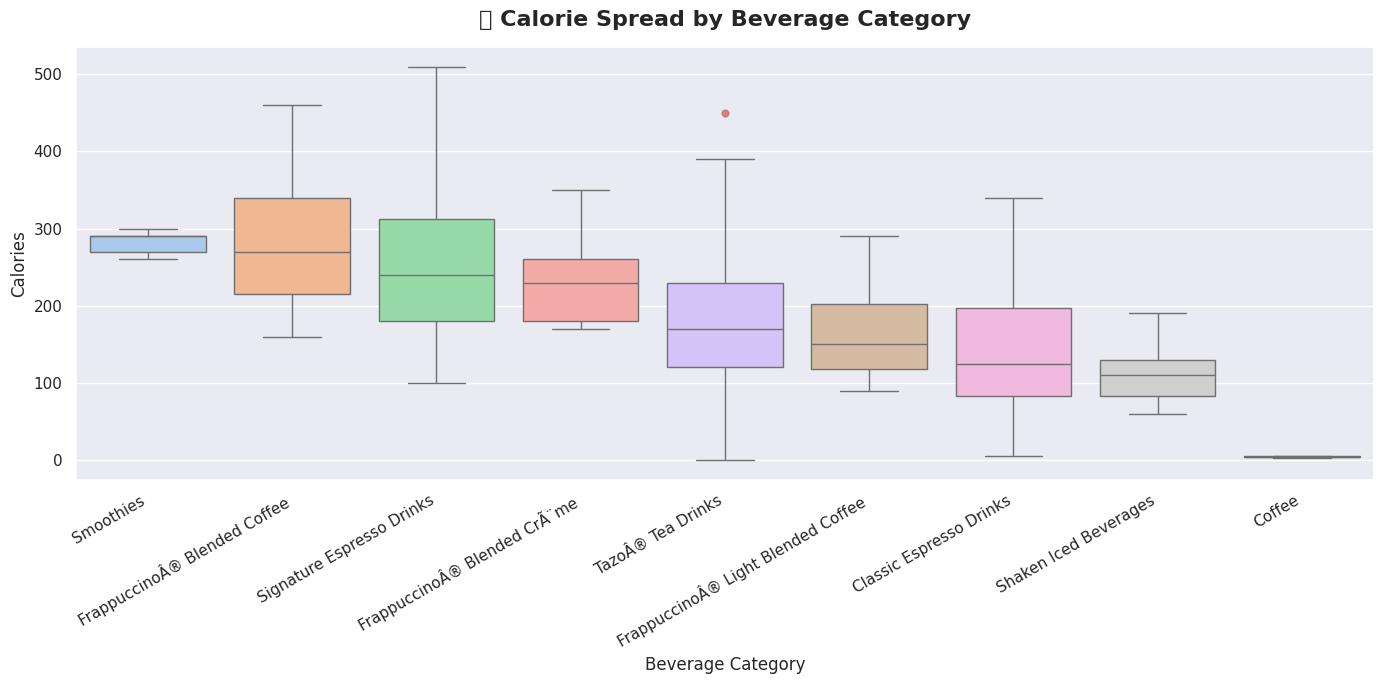

In [13]:
plt.figure(figsize=(14, 7))

order = expand.groupby('Beverage_category')['Calories'].median().sort_values(ascending=False).index

sns.boxplot(data=expand, x='Beverage_category', y='Calories',
            order=order,
            palette='pastel',
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))

plt.title('📦 Calorie Spread by Beverage Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Beverage Category', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz7_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

 Fun Summary Stats

In [14]:
print('=' * 60)
print('       ☕  STARBUCKS DASHBOARD — FUN FACTS')
print('=' * 60)

print(f'\n🔥 Most calorie drink  : {expand.loc[expand["Calories"].idxmax(), "Beverage"]} ({expand["Calories"].max():.0f} cal)')
print(f'\n🥗 Least calorie drink : {expand.loc[expand["Calories"].idxmin(), "Beverage"]} ({expand["Calories"].min():.0f} cal)')
print(f'\n👑 Highest caffeine    : {expand.loc[expand["Caffeine_mg"].idxmax(), "Beverage"]} ({expand["Caffeine_mg"].max():.0f} mg)')
print(f'\n🍬 Sweetest drink      : {expand.loc[expand["Sugars_g"].idxmax(), "Beverage"]} ({expand["Sugars_g"].max():.0f}g sugar)')
print(f'\n📊 Avg drink calories  : {expand["Calories"].mean():.1f} cal')

# Fix: drop NaN before averaging food calories
food_avg_cal = food["Calories"].dropna().mean()
print(f'\n🍔 Avg food calories   : {food_avg_cal:.1f} cal')

print(f'\n🏆 Highest cal category: {expand.groupby("Beverage_category")["Calories"].mean().idxmax()}')

print('\n' + '=' * 60)
print('✅  Dashboard Complete! ☕')
print('=' * 60)

       ☕  STARBUCKS DASHBOARD — FUN FACTS

🔥 Most calorie drink  : White Chocolate Mocha (Without Whipped Cream) (510 cal)

🥗 Least calorie drink : TazoÂ® Tea (0 cal)

👑 Highest caffeine    : Brewed Coffee (410 mg)

🍬 Sweetest drink      : Java Chip (Without Whipped Cream) (84g sugar)

📊 Avg drink calories  : 193.9 cal

🍔 Avg food calories   : 356.6 cal

🏆 Highest cal category: Smoothies

✅  Dashboard Complete! ☕


In [15]:
print(food.dtypes)
print('\n')
print(food['Calories'].value_counts().head(10))

Item          object
Calories       int64
Fat_g        float64
Carb_g         int64
Fiber_g        int64
Protein_g      int64
dtype: object


Calories
420    7
360    7
330    6
300    4
170    4
460    4
240    4
500    4
480    4
180    4
Name: count, dtype: int64


In [16]:
# Read raw bytes to see what's actually in the file
with open('starbucks-menu-nutrition-food.csv', 'rb') as f:
    raw = f.read(500)
print(raw)

b'\xff\xfe,\x00 \x00C\x00a\x00l\x00o\x00r\x00i\x00e\x00s\x00,\x00 \x00F\x00a\x00t\x00 \x00(\x00g\x00)\x00,\x00 \x00C\x00a\x00r\x00b\x00.\x00 \x00(\x00g\x00)\x00,\x00 \x00F\x00i\x00b\x00e\x00r\x00 \x00(\x00g\x00)\x00,\x00 \x00P\x00r\x00o\x00t\x00e\x00i\x00n\x00 \x00(\x00g\x00)\x00\n\x00C\x00h\x00o\x00n\x00g\x00a\x00 \x00B\x00a\x00g\x00e\x00l\x00,\x003\x000\x000\x00,\x005\x00,\x005\x000\x00,\x003\x00,\x001\x002\x00\n\x008\x00-\x00G\x00r\x00a\x00i\x00n\x00 \x00R\x00o\x00l\x00l\x00,\x003\x008\x000\x00,\x006\x00,\x007\x000\x00,\x007\x00,\x001\x000\x00\n\x00A\x00l\x00m\x00o\x00n\x00d\x00 \x00C\x00r\x00o\x00i\x00s\x00s\x00a\x00n\x00t\x00,\x004\x001\x000\x00,\x002\x002\x00,\x004\x005\x00,\x003\x00,\x001\x000\x00\n\x00A\x00p\x00p\x00l\x00e\x00 \x00F\x00r\x00i\x00t\x00t\x00e\x00r\x00,\x004\x006\x000\x00,\x002\x003\x00,\x005\x006\x00,\x002\x00,\x007\x00\n\x00B\x00a\x00n\x00a\x00n\x00a\x00 \x00N\x00u\x00t\x00 \x00B\x00r\x00e\x00a\x00d\x00,\x004\x002\x000\x00,\x002\x002\x00,\x005\x002\x00,\x002\x00

In [17]:
from google.colab import files

# Download all visualization images
files.download('viz1_top10_calories.png')
files.download('viz2_category_avg.png')
files.download('viz3_sugar_scatter.png')
files.download('viz4_caffeine.png')
files.download('viz5_radar.png')
files.download('viz6_food_vs_drinks.png')
files.download('viz7_boxplot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>